In [39]:
!pip install torchmetrics -q

In [2]:
import torch
from torch.utils.data import TensorDataset, DataLoader
import torch.nn as nn
import torchmetrics
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [3]:
df = pd.read_csv("Titanic-Dataset.csv")
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
df.shape

(891, 12)

In [5]:
df.duplicated().sum()

np.int64(0)

In [6]:
df['Ticket'].value_counts(dropna=False)

,count
Ticket,
347082,7
1601,7
CA. 2343,7
3101295,6
CA 2144,6
...,...
PC 17590,1
17463,1
330877,1


In [7]:
df['Cabin'].value_counts(dropna=False)

,count
Cabin,
NaN,687
G6,4
C23 C25 C27,4
B96 B98,4
F2,3
...,...
E17,1
A24,1
C50,1


In [8]:
df.drop(columns=['PassengerId','Ticket','Cabin'],inplace=True)

In [9]:
df.isna().sum()

,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Fare,0
Embarked,2


In [10]:
df['Embarked'].value_counts(dropna=False)

,count
Embarked,
S,644
C,168
Q,77
NaN,2


In [11]:
df['Age'].value_counts(dropna=False)

,count
Age,
NaN,177
24.00,30
22.00,27
18.00,26
28.00,25
...,...
24.50,1
0.67,1
0.42,1


In [12]:
df['Name'].value_counts(dropna=False)

,count
Name,
"Dooley, Mr. Patrick",1
"Braund, Mr. Owen Harris",1
"Cumings, Mrs. John Bradley (Florence Briggs Thayer)",1
"Heikkinen, Miss. Laina",1
"Futrelle, Mrs. Jacques Heath (Lily May Peel)",1
...,...
"Hewlett, Mrs. (Mary D Kingcome)",1
"Vestrom, Miss. Hulda Amanda Adolfina",1
"Andersson, Mr. Anders Johan",1


In [13]:
df.drop(['Name','Fare'],axis=1,inplace=True)

In [14]:
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Embarked
0,0,3,male,22.0,1,0,S
1,1,1,female,38.0,1,0,C
2,1,3,female,26.0,0,0,S
3,1,1,female,35.0,1,0,S
4,0,3,male,35.0,0,0,S


In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    int64  
 1   Pclass    891 non-null    int64  
 2   Sex       891 non-null    object 
 3   Age       714 non-null    float64
 4   SibSp     891 non-null    int64  
 5   Parch     891 non-null    int64  
 6   Embarked  889 non-null    object 
dtypes: float64(1), int64(4), object(2)
memory usage: 48.9+ KB


In [16]:
df['Survived'].value_counts(dropna=False)

,count
Survived,
0,549
1,342


In [17]:
X = df.drop('Survived',axis=1)
y = df['Survived']

In [27]:
from sklearn.model_selection import train_test_split

X_train_full, X_test, y_train_full, y_test = train_test_split(X,y,random_state=42,stratify=y)
X_train, X_valid, y_train, y_valid = train_test_split(X_train_full,y_train_full,random_state=42,stratify=y_train_full)
X_train.shape, X_valid.shape, X_test.shape

((501, 6), (167, 6), (223, 6))

In [28]:
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

cat_cols = ['Sex', 'Embarked']
num_cols = ['Pclass', 'Age', 'SibSp', 'Parch']

cat_pipeline = Pipeline([
    ('imp', SimpleImputer(strategy='most_frequent')),
    ('ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=False)),
])
num_pipeline = Pipeline(
    [('imp', SimpleImputer(strategy='median')),
     ('scl', StandardScaler()),
])

preprocessing = ColumnTransformer(
    transformers=[
        ('CAT', cat_pipeline, cat_cols),
        ('NUM', num_pipeline, num_cols),
    ]
)

X_train_proc = preprocessing.fit_transform(X_train)
X_valid_proc = preprocessing.transform(X_valid)
X_test_proc = preprocessing.transform(X_test)

X_train_tensor = torch.tensor(X_train_proc, dtype=torch.float32)
X_valid_tensor = torch.tensor(X_valid_proc, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test_proc, dtype=torch.float32)

y_train_tensor = torch.tensor(
    y_train.to_numpy(), dtype=torch.float32
).view(-1, 1)
y_valid_tensor = torch.tensor(
    y_valid.to_numpy(), dtype=torch.float32
).view(-1, 1)
y_test_tensor = torch.tensor(y_test.to_numpy(), dtype=torch.float32).view(
    -1, 1
)

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
valid_dataset = TensorDataset(X_valid_tensor, y_valid_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
valid_loader = DataLoader(valid_dataset, batch_size=32)
test_loader = DataLoader(test_dataset, batch_size=32)

print("X_train shape:", X_train_tensor.shape)
print("X_valid shape:", X_valid_tensor.shape)
print("X_test shape: ", X_test_tensor.shape)

X_train shape: torch.Size([501, 9])
X_valid shape: torch.Size([167, 9])
X_test shape:  torch.Size([223, 9])


In [29]:
if torch.cuda.is_available():
    device = "cuda"
elif torch.backends.mps.is_available():
    device = "mps"
else:
    device = "cpu"

device

'cpu'

In [30]:
def train(model, optimizer, criterion, metric, train_loader, valid_loader, n_epochs):
	history = {
		'loss' : [],
		'train_metric' : [],
		'valid_metric' : [],
	}
	for epoch in range(n_epochs):
		# Training
		total_loss = 0
		metric.reset()
		for X_batch, y_batch in train_loader:
			X_batch, y_batch = X_batch.to(device), y_batch.to(device)
			model.train()
			y_pred = model(X_batch)
			loss = criterion(y_pred, y_batch)
			total_loss += loss.item()
			loss.backward()
			optimizer.step()

			optimizer.zero_grad()
			metric.update(y_pred, y_batch)

		avg_loss = total_loss / len(train_loader)
		history['loss'].append(avg_loss)

		avg_metric_train = metric.compute().item()
		history['train_metric'].append(avg_metric_train)

		# Evaluation
		model.eval()
		metric.reset()
		with torch.no_grad():
			for X_batch, y_batch in valid_loader:
				X_batch, y_batch = X_batch.to(device), y_batch.to(device)
				y_pred = model(X_batch)
				metric.update(y_pred, y_batch)

		avg_metric_valid = metric.compute().item()
		history['valid_metric'].append(avg_metric_valid)

		print(
			f'Epoch: {epoch+1}/{n_epochs}, '
			+f'Loss: {round(avg_loss,3)}, '
			+f'Train Metric: {round(avg_metric_train,3)}, '
			+f'Valid Metric: {round(avg_metric_valid,3)}'
		)

		# if epoch>=2:
		# 	break
	return history

def plot_history(history, n_epochs, metric):
    plt.plot(np.arange(n_epochs) + 1, history['train_metric'], linestyle='--', color='r', marker='.', label='Train')
    plt.plot(np.arange(n_epochs) + 1, history['valid_metric'], linestyle='--', color='b', marker='.', label='Valid')
    plt.legend()
    plt.grid()
    plt.xlabel('Epochs')
    plt.ylabel(f'{metric.__class__.__name__}')
    plt.show()

n_features: 9
Epoch: 1/6, Loss: 0.673, Train Metric: 0.581, Valid Metric: 0.599
Epoch: 2/6, Loss: 0.637, Train Metric: 0.617, Valid Metric: 0.689
Epoch: 3/6, Loss: 0.6, Train Metric: 0.711, Valid Metric: 0.784
Epoch: 4/6, Loss: 0.557, Train Metric: 0.774, Valid Metric: 0.796
Epoch: 5/6, Loss: 0.509, Train Metric: 0.802, Valid Metric: 0.796
Epoch: 6/6, Loss: 0.472, Train Metric: 0.802, Valid Metric: 0.796


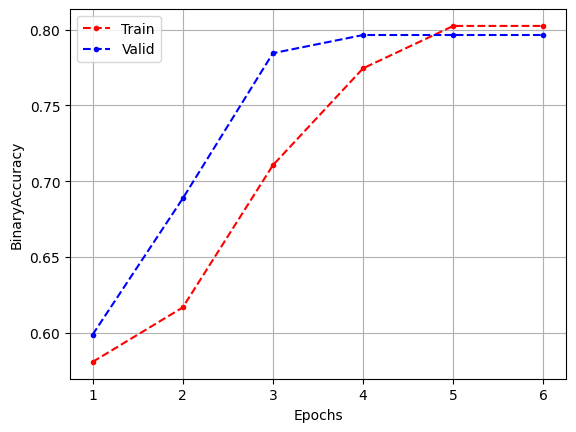

In [37]:
learning_rate = 0.1
n_epochs= 6
n_features = preprocessing.transform(X_train).shape[1]
print("n_features:", n_features)

model = nn.Sequential(
	nn.Linear(in_features=n_features, out_features=50),
	nn.LeakyReLU(),
	nn.Linear(in_features=50, out_features=80),
	nn.LeakyReLU(),
	nn.Linear(in_features=80, out_features=1),
  nn.Sigmoid()
).to(device)

criterion = nn.BCELoss()
optimizer = torch.optim.SGD(params=model.parameters(), lr=learning_rate)
metric = torchmetrics.Accuracy(task='binary').to(device)
history = train(model, optimizer, criterion, metric, train_loader, valid_loader, n_epochs)
plot_history(history, n_epochs, metric)

In [38]:
model.eval()
metric.reset()
with torch.inference_mode():
	for X_batch, y_batch in test_loader:
		X_batch, y_batch = X_batch.to(device), y_batch.to(device)
		y_pred_logits = model(X_batch)
		y_pred = y_pred_logits.argmax(dim=1)
		metric.update(y_pred_logits, y_batch)
avg_metric_test = metric.compute().item()
print(f'Test Metric: {round(avg_metric_test,3)}')

Test Metric: 0.78
